This notebook documents the full causal identification attempt for the recidivism-education project.
It proceeds in three stages:

1. Construct the recidivism outcome from individual-level spell sequences
2. Build the state-year panel and assign treatment groups
3. Test whether the DiD assumptions hold for each candidate treatment state

The conclusion — documented with data — is that no treatment state in the NCRP supports
a clean difference-in-differences design. This is itself a finding about the limits of
administrative data for causal inference in this setting.

**Candidate treatment states and enactment years** (from statute research):
- Ohio (FIPS 39): 1999
- New Jersey (FIPS 34): 2009
- Michigan (FIPS 26): 1998

**Always-treated states** (enacted before 1991, excluded from DiD):
- California (6), New Mexico (35), Oregon (41), Texas (48)

**Control group**: never-treated states only

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Step 1: Construct recidivism outcome

An inmate recidivates if they have a subsequent spell beginning within 3 years of their release year.
We use `ABT_INMATE_ID` to link spells, `RELEASEYR` as the release date, and `ADMITYR` of the next
spell as the return date. The recidivism rate for a state-year is the share of releases in that cell
who returned within 3 years.

In [11]:
df = pd.read_parquet("../data/processed/NCRP_1991_2020_clean.parquet")
print(f"Loaded: {df.shape}")
df.head()

Loaded: (13407592, 14)


,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,ADMITYR,RELEASEYR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE
0,A012021000000090128,1,1.0,2,2013,2013,4,8,1.0,5,5,0,3.0,1
1,A012021000000110168,1,1.0,1,2004,<NA>,4,3,1.0,5,<NA>,9,NaN,1
2,A012021000000090187,1,1.0,2,2009,2009,0,11,NaN,1,1,0,1.0,1
3,A012021000000010425,1,3.0,3,2016,2016,2,12,NaN,3,3,0,3.0,1
4,A012021000000090117,1,1.0,1,2009,2017,4,4,NaN,1,2,3,1.0,1


In [12]:
# Keep only rows with a valid release year
released = df[df["RELEASEYR"].notna()].copy()
print(f"Rows with valid RELEASEYR: {len(released):,} ({len(released)/len(df)*100:.1f}% of total)")

# Sort each inmate's spells by admission year
released = released.sort_values(["ABT_INMATE_ID", "ADMITYR"])

# For each spell, find the next admission year for the same inmate
released["NEXT_ADMITYR"] = released.groupby("ABT_INMATE_ID")["ADMITYR"].shift(-1)

# Flag recidivism: returned within 3 years of release
released["RECIDIVATED"] = (
    released["NEXT_ADMITYR"].notna() &
    ((released["NEXT_ADMITYR"] - released["RELEASEYR"]) <= 3) &
    ((released["NEXT_ADMITYR"] - released["RELEASEYR"]) >= 0)
).astype(int)

print(f"\nOverall recidivism rate: {released['RECIDIVATED'].mean():.3f}")
print(f"Total releases measured: {len(released):,}")
print(f"Recidivated within 3yr:  {released['RECIDIVATED'].sum():,}")

Rows with valid RELEASEYR: 12,433,882 (92.7% of total)

Overall recidivism rate: 0.391
Total releases measured: 12,433,882
Recidivated within 3yr:  4,857,406


## Step 2: Aggregate to state-year panel

Group by state and release year. Restrict to 1991-2017 — releases after 2017 cannot be followed
for 3 full years within the data window (which ends in 2020).

In [13]:
panel = (
    released
    .groupby(["STATE", "RELEASEYR"])
    .agg(
        recidivism_rate=("RECIDIVATED", "mean"),
        n_releases=("RECIDIVATED", "count"),
        avg_age_admit=("AGEADMIT", "mean"),
        pct_male=("SEX", lambda x: (x.astype(int) == 1).mean()),
        pct_violent=("OFFGENERAL", lambda x: (x.astype(int) == 1).mean()),
    )
    .reset_index()
)

panel = panel.rename(columns={"RELEASEYR": "YEAR"})
panel["STATE"] = panel["STATE"].astype(int)
panel["YEAR"]  = panel["YEAR"].astype(int)

# Restrict to years where 3-year follow-up is fully observed
panel = panel[panel["YEAR"].between(1991, 2017)]

print(f"Panel shape: {panel.shape}")
print(f"States: {panel['STATE'].nunique()}")
print(f"Years:  {panel['YEAR'].min()} to {panel['YEAR'].max()}")
panel.head(10)

Panel shape: (671, 7)
States: 44
Years:  1991 to 2017


,STATE,YEAR,recidivism_rate,n_releases,avg_age_admit,pct_male,pct_violent
0,1,2007,0.367149,11957,2.343063,0.863511,0.221544
1,1,2008,0.370745,12750,2.403137,0.871529,0.185804
2,1,2009,0.356662,13374,2.400479,0.870944,0.178481
3,1,2010,0.362679,13290,2.391121,0.872837,0.172460
4,1,2011,0.346107,12343,2.382403,0.867374,0.185773
5,1,2012,0.350929,12427,2.402511,0.868754,0.179046
6,1,2013,0.342974,12759,2.407399,0.863077,0.174779
7,1,2014,0.339618,13153,2.450011,0.854330,0.174333
8,1,2015,0.331055,12584,2.479259,0.861014,0.182533
9,1,2016,0.345502,12327,2.487223,0.858522,0.206052


In [14]:
ALWAYS_TREATED  = {6, 35, 41, 48}        # CA, NM, OR, TX — enacted before 1991
TREATMENT_YEARS = {39: 1999, 34: 2009}   # Ohio, New Jersey — primary candidates

# Drop always-treated states from DiD panel
panel = panel[~panel["STATE"].isin(ALWAYS_TREATED)].copy()
print(f"Panel after dropping always-treated states: {panel.shape}")

# G = first treatment year; 0 = never treated
panel["G"] = panel["STATE"].map(TREATMENT_YEARS).fillna(0).astype(int)

print("\nCohort sizes (unique states per treatment year):")
print(panel.groupby("G")["STATE"].nunique().rename("n_states"))

panel.to_parquet("../data/processed/state_year_panel.parquet", index=False)
print("\nSaved state-year panel.")

Panel after dropping always-treated states: (625, 7)

Cohort sizes (unique states per treatment year):
G
0       38
1999     1
2009     1
Name: n_states, dtype: int64

Saved state-year panel.


## Step 3: Parallel trends checks

Before estimating DiD, we test whether each candidate treatment state was on a similar
recidivism trajectory as never-treated states before the policy was enacted.
If trends diverge pre-treatment, the DiD assumption fails and the estimate is not causal.

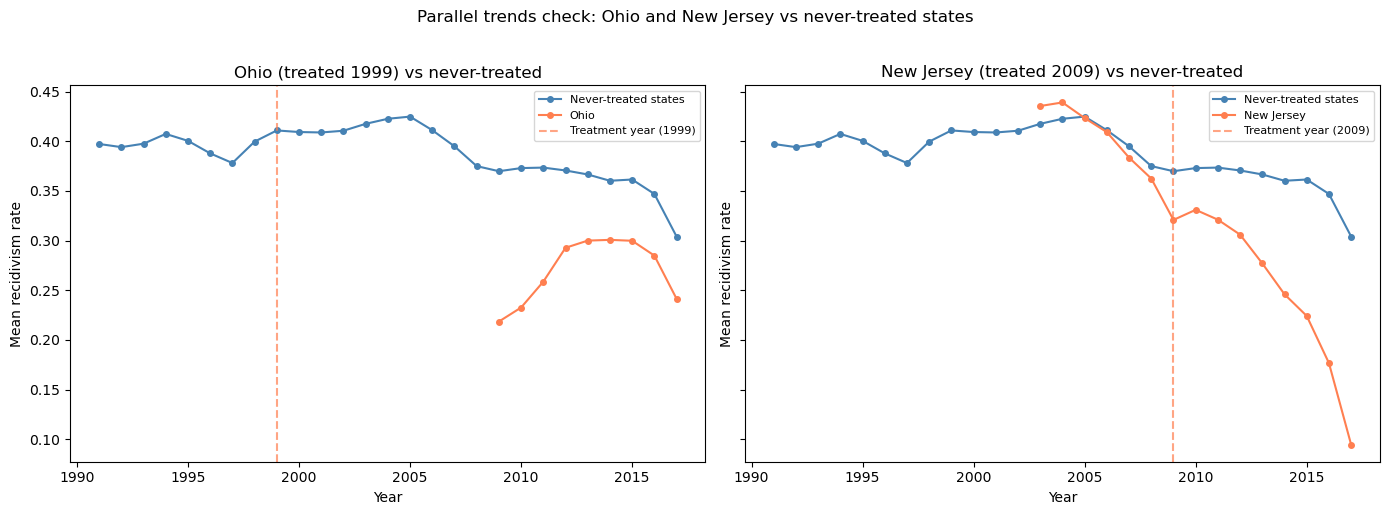

In [6]:
never_avg = panel[panel["G"] == 0].groupby("YEAR")["recidivism_rate"].mean()

cohort_info = {
    39: {"label": "Ohio",       "treat_yr": 1999},
    34: {"label": "New Jersey", "treat_yr": 2009},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (fips, info) in zip(axes, cohort_info.items()):
    cohort_avg = panel[panel["STATE"] == fips].groupby("YEAR")["recidivism_rate"].mean()
    ax.plot(never_avg.index, never_avg.values,
            color="steelblue", marker="o", markersize=4, label="Never-treated states")
    ax.plot(cohort_avg.index, cohort_avg.values,
            color="coral", marker="o", markersize=4, label=info["label"])
    ax.axvline(x=info["treat_yr"], color="coral", linestyle="--",
               alpha=0.7, label=f"Treatment year ({info['treat_yr']})")
    ax.set_title(f"{info['label']} (treated {info['treat_yr']}) vs never-treated")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean recidivism rate")
    ax.legend(fontsize=8)

plt.suptitle("Parallel trends check: Ohio and New Jersey vs never-treated states", y=1.02)
plt.tight_layout()
plt.show()

### Finding: Ohio and New Jersey cannot be used as treatment states

The plots reveal two distinct problems:

**Ohio** does not appear in the panel until 2009, that is a full decade after the 1999 treatment year.
There is no pre-treatment period to estimate a baseline. This is a data reporting issue:
Ohio did not submit release year records to BJS before ~2006, confirmed below.

**New Jersey** shows a pre-existing downward trend starting in 2003, six years before the 2009
treatment, while never-treated states are flat. The parallel trends assumption fails before
treatment even begins.

In [7]:
# Year-by-year release counts for Ohio and New Jersey
for fips, name in [(39, "Ohio"), (34, "New Jersey")]:
    subset = panel[panel["STATE"] == fips][["YEAR", "recidivism_rate", "n_releases"]]
    print(f"\n{name} (FIPS {fips}):")
    print(subset.to_string(index=False))

# Confirm Ohio's RELEASEYR reporting gap in the raw data
print("\n--- Ohio RELEASEYR reporting in raw NCRP ---")
ohio_raw = df[df["STATE"].astype(int) == 39][["ADMITYR", "RELEASEYR"]].copy()
print(f"Overall share missing RELEASEYR: {ohio_raw['RELEASEYR'].isna().mean():.2%}")
print("\nValid RELEASEYR records by admission year:")
print(ohio_raw.groupby("ADMITYR")["RELEASEYR"].apply(lambda x: x.notna().sum()).to_string())


Ohio (FIPS 39):
 YEAR  recidivism_rate  n_releases
 2009         0.218532       26042
 2010         0.232660       24293
 2011         0.258712       22554
 2012         0.292790       21179
 2013         0.300029       21028
 2014         0.300780       21421
 2015         0.299865       21543
 2016         0.284961       22375
 2017         0.241496       22108

New Jersey (FIPS 34):
 YEAR  recidivism_rate  n_releases
 2003         0.435526       14277
 2004         0.439119       14668
 2005         0.423425       13686
 2006         0.409262       14057
 2007         0.383595       14252
 2008         0.362535       13698
 2009         0.320860       12320
 2010         0.331014       11930
 2011         0.321093       11492
 2012         0.306034       10855
 2013         0.277105       10570
 2014         0.246003       10008
 2015         0.224207        9518
 2016         0.176792        8609
 2017         0.094665        8060

--- Ohio RELEASEYR reporting in raw NCRP ---
Over

### Michigan: sensitivity check

Michigan (FIPS 26, treated 1998) was not in the primary treatment group because its statute
(MCL § 791.233) was unconfirmed as automatic enrollment. However it has release data going
back to 1991, giving 7 pre-treatment years. We check it as a fallback.

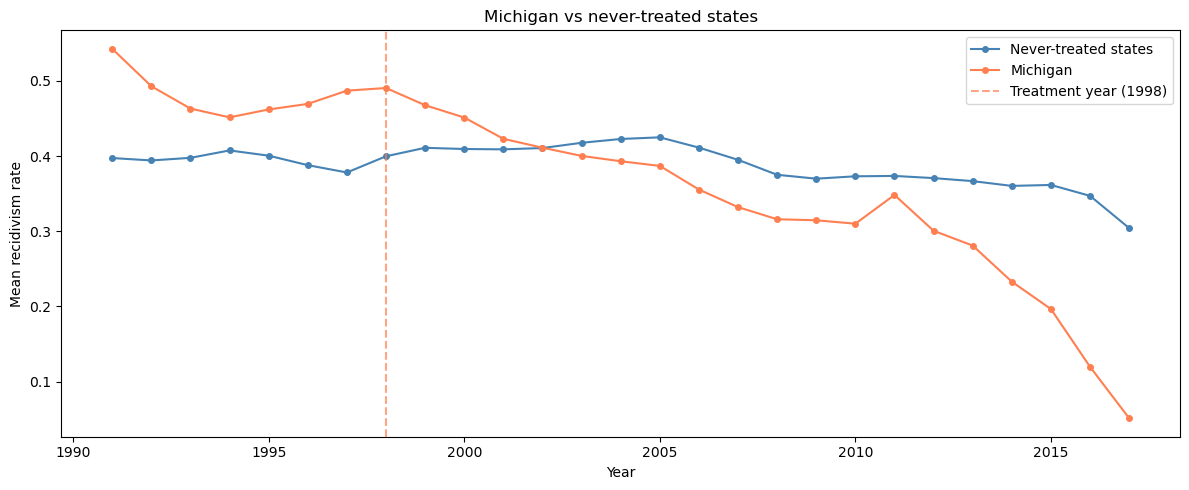

In [8]:
never_avg = panel[panel["G"] == 0].groupby("YEAR")["recidivism_rate"].mean()
mi_avg    = panel[panel["STATE"] == 26].groupby("YEAR")["recidivism_rate"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(never_avg.index, never_avg.values,
        color="steelblue", marker="o", markersize=4, label="Never-treated states")
ax.plot(mi_avg.index, mi_avg.values,
        color="coral", marker="o", markersize=4, label="Michigan")
ax.axvline(x=1998, color="coral", linestyle="--", alpha=0.7, label="Treatment year (1998)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean recidivism rate")
ax.set_title("Michigan vs never-treated states")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Quantify the pre-treatment trend divergence
mi_pre    = mi_avg[mi_avg.index < 1998]
never_pre = never_avg[never_avg.index < 1998]

print("Michigan pre-treatment trend (1991-1997):")
print(mi_pre.round(4))
print("\nNever-treated pre-treatment trend (1991-1997):")
print(never_pre.round(4))

print(f"\nMichigan change 1991-1997:      {mi_pre.iloc[-1] - mi_pre.iloc[0]:.4f}")
print(f"Never-treated change 1991-1997: {never_pre.iloc[-1] - never_pre.iloc[0]:.4f}")

Michigan pre-treatment trend (1991-1997):
YEAR
1991    0.5426
1992    0.4928
1993    0.4631
1994    0.4514
1995    0.4619
1996    0.4693
1997    0.4869
Name: recidivism_rate, dtype: float64

Never-treated pre-treatment trend (1991-1997):
YEAR
1991    0.3973
1992    0.3941
1993    0.3976
1994    0.4074
1995    0.4005
1996    0.3879
1997    0.3781
Name: recidivism_rate, dtype: float64

Michigan change 1991-1997:      -0.0557
Never-treated change 1991-1997: -0.0192


### Finding: Michigan also fails the parallel trends test

Michigan starts at 0.54 in 1991 vs 0.40 for never-treated states — a level difference of 14
percentage points that would need to be constant for DiD to work. Instead, Michigan declines
by 0.056 pre-treatment while never-treated states decline by only 0.019. The trends are not parallel.

Additionally, Michigan's Truth in Sentencing reform (enacted 1998-2000) requires prisoners to
serve 100% of their minimum sentence and dramatically changed who gets released and when.
This policy coincides almost exactly with the education mandate and cannot be separated from it.
The post-treatment drop to 0.05 by 2017 is implausibly large for a single education policy.